In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [2]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_test.shape

(10000, 28, 28)

In [4]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

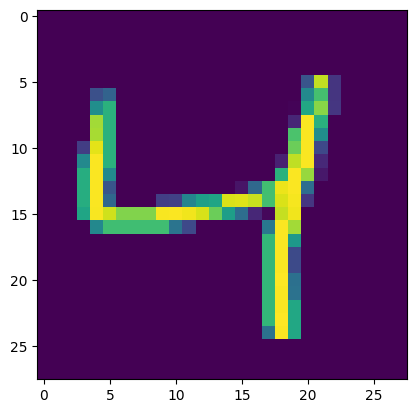

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[2])

In [6]:
X_train = X_train/255
X_test = X_test/255

In [7]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [8]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [11]:
history = model.fit(X_train,y_train,epochs=25,validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9179 - loss: 0.2821 - val_accuracy: 0.9589 - val_loss: 0.1433
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9660 - loss: 0.1170 - val_accuracy: 0.9685 - val_loss: 0.1067
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9751 - loss: 0.0797 - val_accuracy: 0.9663 - val_loss: 0.1155
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9796 - loss: 0.0622 - val_accuracy: 0.9725 - val_loss: 0.0936
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9854 - loss: 0.0458 - val_accuracy: 0.9741 - val_loss: 0.0962
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9876 - loss: 0.0383 - val_accuracy: 0.9738 - val_loss: 0.0933
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9899 - loss: 0.0315 - val_accuracy: 0.9743 - val_loss: 0.1079
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9908 - loss: 0.0

In [12]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
y_pred = y_prob.argmax(axis=1)

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9776

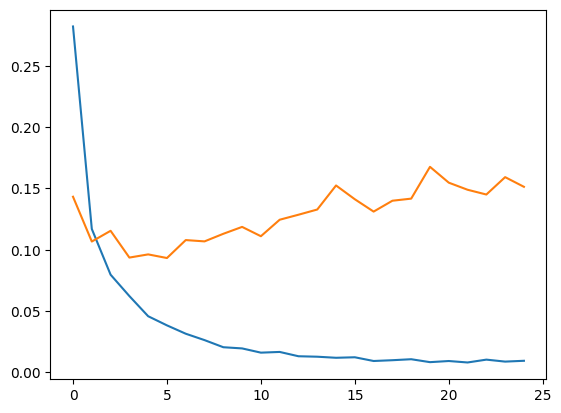

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

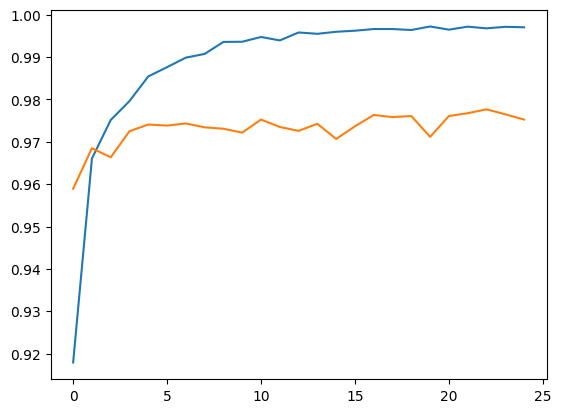

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

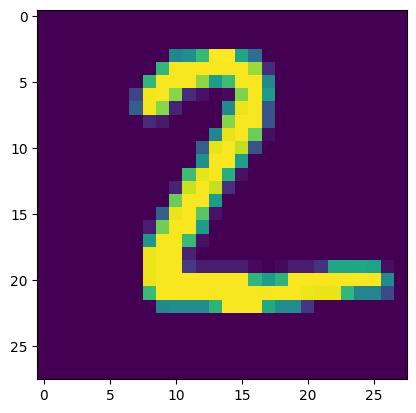

In [17]:
plt.imshow(X_test[1])

In [18]:
model.predict(X_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([2])

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

# Replace your existing fit() call with:
# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=30,
#     batch_size=128,
#     callbacks=callbacks
# )


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.96      0.98      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



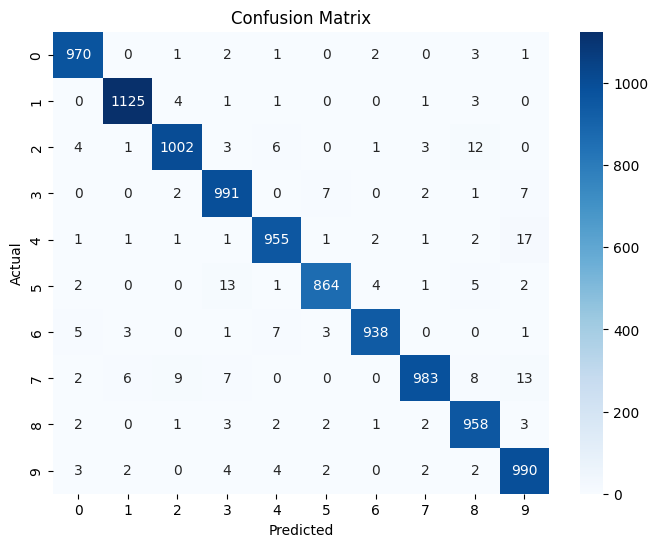

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pred = np.argmax(model.predict(X_test), axis=1)
true = np.argmax(y_test, axis=1) if len(y_test.shape)>1 else y_test

print(classification_report(true, pred))

cm = confusion_matrix(true, pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


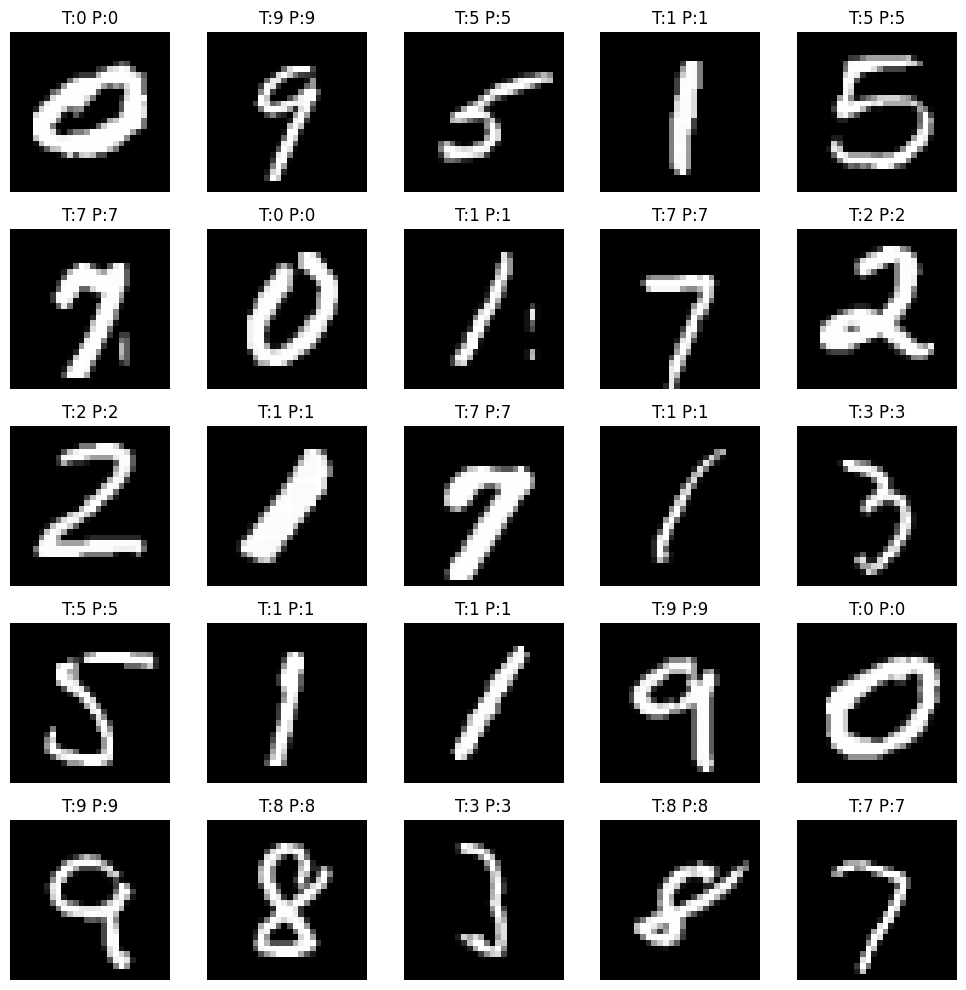

Model saved.


In [21]:
idx = np.random.choice(len(X_test), 25, replace=False)
plt.figure(figsize=(10,10))
for i,j in enumerate(idx):
    plt.subplot(5,5,i+1)
    plt.imshow(X_test[j].reshape(28,28), cmap='gray')
    plt.title(f'T:{true[j]} P:{pred[j]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

model.save("mnist_classifier.keras")
print("Model saved.")


CNN Model Comparison

In [23]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),
    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn,y_test),
    epochs=20,
    batch_size=128,
    callbacks=callbacks
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 163ms/step - accuracy: 0.8810 - loss: 0.3972 - val_accuracy: 0.8707 - val_loss: 0.4058 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 168ms/step - accuracy: 0.9610 - loss: 0.1313 - val_accuracy: 0.9870 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 164ms/step - accuracy: 0.9707 - loss: 0.0994 - val_accuracy: 0.9884 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 163ms/step - accuracy: 0.9755 - loss: 0.0841 - val_accuracy: 0.9875 - val_loss: 0.0394 - learning_rate: 0.0010
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 161ms/step - accuracy: 0.9779 - loss: 0.0752 - val_accuracy: 0.9882 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 169ms/step - accuracy: 0.9830 - loss: 0.0571 - val_accuracy: 0.9904 - val_loss: 0.0309 - learning_rate: 5.0000e-04
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 163ms/step - accuracy:

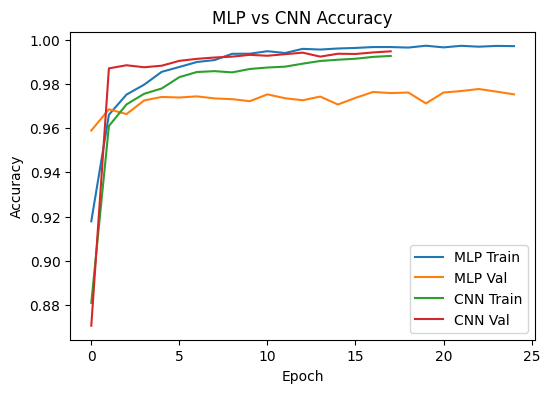

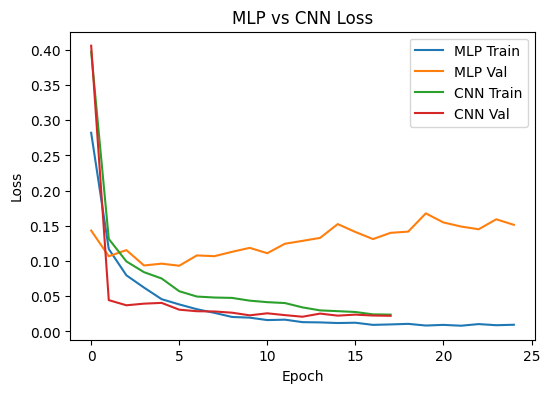

In [24]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'],label='MLP Train')
plt.plot(history.history['val_accuracy'],label='MLP Val')
plt.plot(history_cnn.history['accuracy'],label='CNN Train')
plt.plot(history_cnn.history['val_accuracy'],label='CNN Val')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("MLP vs CNN Accuracy")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'],label='MLP Train')
plt.plot(history.history['val_loss'],label='MLP Val')
plt.plot(history_cnn.history['loss'],label='CNN Train')
plt.plot(history_cnn.history['val_loss'],label='CNN Val')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("MLP vs CNN Loss")
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


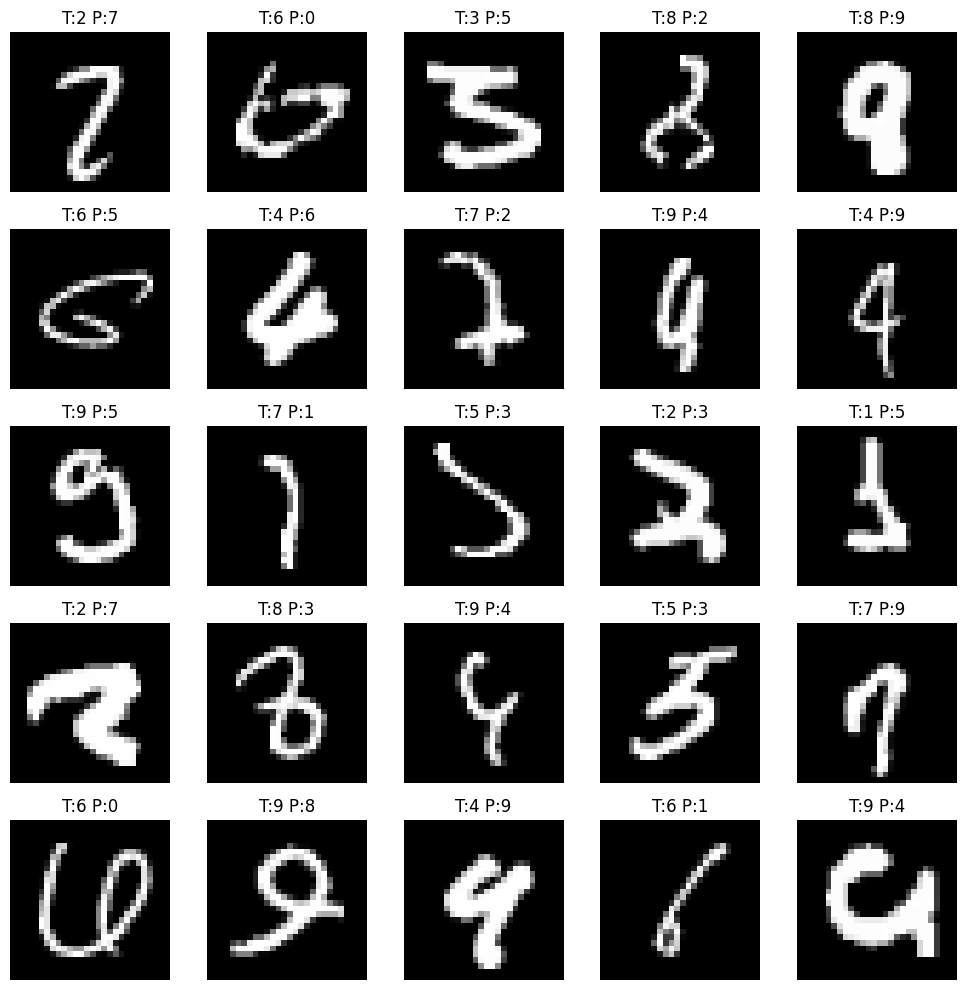

CNN model saved.


In [25]:

pred_cnn = cnn.predict(X_test_cnn).argmax(axis=1)
true = y_test.argmax(axis=1) if len(y_test.shape)>1 else y_test

mis = [i for i in range(len(true)) if pred_cnn[i]!=true[i]][:25]

plt.figure(figsize=(10,10))
for k,i in enumerate(mis):
    plt.subplot(5,5,k+1)
    plt.imshow(X_test_cnn[i].reshape(28,28), cmap='gray')
    plt.title(f'T:{true[i]} P:{pred_cnn[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

cnn.save("mnist_cnn.keras")
print("CNN model saved.")


In [28]:
mlp_loss, mlp_acc = model.evaluate(X_test, y_test, verbose=0)
print("MLP Accuracy:", mlp_acc)
cnn_loss, cnn_acc = cnn.evaluate(X_test_cnn, y_test, verbose=0)
print("CNN Accuracy:", cnn_acc)

MLP Accuracy: 0.9775999784469604
CNN Accuracy: 0.9940999746322632
